# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## Finishing off with Random Forests & Ensemble

In [1]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [2]:
# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

In [6]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [7]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [8]:
# Another import after Logging in to Hugging Face - thank you Trung N.!

from items import Item

In [9]:
# Load in the test pickle file:

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [10]:
print(test[5])

<Wireless Temperature & Humidity Bluetooth Smart Sensor for iPhone/Android - Thermometer/Hygrometer to Monitor Climate for Your Home, Refrigerator, Humidor, Reptiles, Baby, Guitar (Black, 2 Sensors) = $54.99>


In [11]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [12]:
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

In [13]:
#result

In [14]:
#vectors

In [15]:
results = collection.get()
print("IDs:", results['ids'])
print("Metadatas:", results.get('metadatas', []))
print("Documents:", results.get('documents', [])) 
print("Embeddings:", results.get('embeddings', [])) 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Embeddings: None


In [ ]:
#prices

# Random Forest

We will now train a Random Forest model.

Can you spot the difference from what we did in Week 6? In week 6 we used the word2vec model to form vectors; this time we'll use the vectors we already have in Chroma, from the SentenceTransformer model.

In [14]:
# This next line takes an hour on my M1 Mac!

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(vectors, prices)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# Save the model to a file

joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [16]:
# Load it back in again

rf_model = joblib.load('random_forest_model.pkl')

In [17]:
from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent

In [18]:
specialist = SpecialistAgent()
frontier = FrontierAgent(collection)
random_forest = RandomForestAgent()

In [19]:
def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

In [20]:
def rf(item):
    return random_forest.price(description(item))

/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


1: Guess: $66.05 Truth: $65.99 Error: $0.06 SLE: 0.00 Item: Setpower Insulated Protective Cover for ...
2: Guess: $148.81 Truth: $9.68 Error: $139.13 SLE: 6.97 Item: TUAIC Refrigerator Door Light Switch 2 F...
3: Guess: $134.21 Truth: $155.98 Error: $21.77 SLE: 0.02 Item: Kegco Secondary Regulator, 3 Product, Ch...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


4: Guess: $31.16 Truth: $5.59 Error: $25.57 SLE: 2.51 Item: MHY62044106 Refrigerator Door Spring 2Pc...
5: Guess: $105.30 Truth: $98.40 Error: $6.90 SLE: 0.00 Item: Ice-O-Matic 9131111-01 Float Valve
6: Guess: $54.38 Truth: $54.99 Error: $0.61 SLE: 0.00 Item: Wireless Temperature & Humidity Bluetoot...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


7: Guess: $49.20 Truth: $5.71 Error: $43.49 SLE: 4.05 Item: 3Inch Thermometer Hygrometer for Indoor ...
8: Guess: $34.18 Truth: $9.53 Error: $24.65 SLE: 1.46 Item: GE WH1X2754 GE Timer Knob Assembly,white
9: Guess: $19.31 Truth: $11.24 Error: $8.07 SLE: 0.26 Item: newlifeapp 33001003 Dryer Lint Screen Fi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


10: Guess: $36.68 Truth: $12.88 Error: $23.80 SLE: 1.00 Item: Away NV350 NV351 NV352 NV355 NV356 NV357...
11: Guess: $87.87 Truth: $99.99 Error: $12.12 SLE: 0.02 Item: IM116000 Refrigerator Ice Maker Genuine ...
12: Guess: $20.51 Truth: $16.99 Error: $3.52 SLE: 0.03 Item: 2 PACKS DLSC002 Water Filter Compatible ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


13: Guess: $38.54 Truth: $12.74 Error: $25.80 SLE: 1.12 Item: STANCO METAL PROD 410-8 8"Elec NonstickS...
14: Guess: $21.19 Truth: $10.95 Error: $10.24 SLE: 0.38 Item: GE WB32X10012 6-Inch Drip Pan
15: Guess: $63.84 Truth: $66.50 Error: $2.66 SLE: 0.00 Item: Edgewater Parts WH23X10016 Drain Pump Co...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


16: Guess: $13.65 Truth: $11.99 Error: $1.66 SLE: 0.01 Item: Elyum Size 04 Cone Coffee Filters, Natur...
17: Guess: $32.24 Truth: $49.95 Error: $17.71 SLE: 0.18 Item: Everydrop by Whirlpool Ice and Water Ref...
18: Guess: $42.80 Truth: $26.92 Error: $15.88 SLE: 0.20 Item: Beverage Air 703-587C Door Gasket


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


19: Guess: $235.36 Truth: $89.98 Error: $145.38 SLE: 0.91 Item: Frigidaire EFIC123-SS Counter Top Maker,...
20: Guess: $127.21 Truth: $25.99 Error: $101.22 SLE: 2.43 Item: Supplying Demand 316203200 316199900 Ele...
21: Guess: $16.54 Truth: $17.99 Error: $1.45 SLE: 0.01 Item: 2-Pack 37001142 Dryer Lint Filter Replac...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


22: Guess: $33.17 Truth: $6.99 Error: $26.18 SLE: 2.11 Item: Qlear-CLWT Premium Replacement Coffee Ma...
23: Guess: $84.86 Truth: $39.99 Error: $44.87 SLE: 0.55 Item: HUBBELL HBL5666CA AC Plug NEMA 6-15 Male...
24: Guess: $30.26 Truth: $13.99 Error: $16.27 SLE: 0.54 Item: Refrigerator Egg Holder With Lid - Super...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


25: Guess: $359.40 Truth: $339.95 Error: $19.45 SLE: 0.00 Item: ZLINE 20.5" Ducted Wall Mount Range Hood...
26: Guess: $39.79 Truth: $67.99 Error: $28.20 SLE: 0.28 Item: Supplying Demand W10919003 W10775446 Top...
27: Guess: $89.52 Truth: $139.00 Error: $49.48 SLE: 0.19 Item: Compatible Ice Maker for Whirlpool GZ25F...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


28: Guess: $43.34 Truth: $8.97 Error: $34.37 SLE: 2.23 Item: Blutoget 6" Louvered Vent Cover for Exte...
29: Guess: $46.48 Truth: $39.65 Error: $6.83 SLE: 0.02 Item: Edgewater Parts WR60X23584, AP5955766, P...
30: Guess: $309.78 Truth: $229.98 Error: $79.80 SLE: 0.09 Item: Winflo 30 In. Convertible Stainless Stee...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


31: Guess: $23.06 Truth: $25.80 Error: $2.74 SLE: 0.01 Item: 383EER3001G 4901ER2003A 383EER3001J 383E...
32: Guess: $28.98 Truth: $11.99 Error: $16.99 SLE: 0.70 Item: 2 PACK AF Compatible Replacement For Sam...
33: Guess: $18.50 Truth: $9.99 Error: $8.51 SLE: 0.33 Item: Poweka Refillable Coffee Capsules Pods R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


34: Guess: $23.10 Truth: $21.99 Error: $1.11 SLE: 0.00 Item: 2-Pack Replacement for Jenn-Air JCD2297K...
35: Guess: $36.36 Truth: $17.90 Error: $18.46 SLE: 0.46 Item: Supco DE019AC Dryer Heating Element Rest...
36: Guess: $79.28 Truth: $84.00 Error: $4.72 SLE: 0.00 Item: Frymaster 826-1526 Common Electric Repla...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


37: Guess: $36.77 Truth: $16.24 Error: $20.53 SLE: 0.62 Item: Plumb Craft 7508800N 5-Foot Washing Mach...
38: Guess: $32.39 Truth: $23.99 Error: $8.40 SLE: 0.08 Item: Overbest DA97-17376B Replacement for Sam...
39: Guess: $19.79 Truth: $6.99 Error: $12.80 SLE: 0.91 Item: Fill 'n Brew Individual Disposable Coffe...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


40: Guess: $27.15 Truth: $24.99 Error: $2.16 SLE: 0.01 Item: Maytag UKF7003 EDR7D1 Comparable Refrige...
41: Guess: $18.53 Truth: $11.61 Error: $6.92 SLE: 0.19 Item: Coffee Filters - Natural Unbleached Brow...
42: Guess: $274.30 Truth: $949.00 Error: $674.70 SLE: 1.53 Item: EdgeStar 20 Inch Wide 4.3 Cu. Ft. Medica...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


43: Guess: $101.25 Truth: $74.00 Error: $27.25 SLE: 0.10 Item: Bosch 00677095 Door Lower Bin, Clear
44: Guess: $56.58 Truth: $22.05 Error: $34.53 SLE: 0.84 Item: Samsung DA34-10120E Switch Door-F
45: Guess: $196.26 Truth: $284.00 Error: $87.74 SLE: 0.14 Item: Jenn air JGA8100ADB Stove Cartridge Asse...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


46: Guess: $52.47 Truth: $91.78 Error: $39.31 SLE: 0.30 Item: Whole Parts Burner Grate (Black) Part # ...
47: Guess: $30.76 Truth: $45.20 Error: $14.44 SLE: 0.14 Item: DEFLECTO SK8WF Supurr-Flex(R) 8ft Dryer ...
48: Guess: $9.20 Truth: $8.69 Error: $0.51 SLE: 0.00 Item: Supco RR109 Receptacle Kit


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


49: Guess: $19.67 Truth: $16.18 Error: $3.49 SLE: 0.03 Item: 33001003 Dryer Lint Screen Filter Replac...
50: Guess: $14.47 Truth: $6.50 Error: $7.97 SLE: 0.52 Item: W10194422 Replacement Light Bulb 40 Watt...
51: Guess: $31.61 Truth: $32.21 Error: $0.60 SLE: 0.00 Item: ForeverPRO 8532165 Drum Light Lens for W...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


52: Guess: $21.15 Truth: $15.39 Error: $5.76 SLE: 0.09 Item: Highcraft Dishwasher Water Supply Line, ...
53: Guess: $29.33 Truth: $17.99 Error: $11.34 SLE: 0.22 Item: 316048413 and 316048414 Stove Burner Dri...
54: Guess: $23.69 Truth: $26.99 Error: $3.30 SLE: 0.02 Item: ReplacementBrand 8171413 Comparable Repl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


55: Guess: $10.56 Truth: $11.99 Error: $1.43 SLE: 0.01 Item: 2-Pack 341241 Dryer Drum Belt Replacemen...
56: Guess: $43.32 Truth: $44.46 Error: $1.14 SLE: 0.00 Item: WP9870163 9870163 Power Nut Kit - Compat...
57: Guess: $112.73 Truth: $15.99 Error: $96.74 SLE: 3.61 Item: Stovetop Extender SE23WHI Oven Gap Guard...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


58: Guess: $135.01 Truth: $129.99 Error: $5.02 SLE: 0.00 Item: COSVALVE Portable Washing Machine 17lbs ...
59: Guess: $31.92 Truth: $24.99 Error: $6.93 SLE: 0.06 Item: AlaSou Washer Dustproof Cover Front Load...
60: Guess: $51.83 Truth: $27.38 Error: $24.45 SLE: 0.39 Item: Honeywell HC26E1004/U Pad for He200, He2...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


61: Guess: $22.90 Truth: $16.95 Error: $5.95 SLE: 0.08 Item: HQRP 2-Pack Wick Filter Compatible with ...
62: Guess: $53.73 Truth: $10.82 Error: $42.91 SLE: 2.35 Item: Whirlpool 8537982 Pad Washer
63: Guess: $29.36 Truth: $19.00 Error: $10.36 SLE: 0.17 Item: Durable Disposable Electric Burner Bibs-...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


64: Guess: $19.58 Truth: $12.98 Error: $6.60 SLE: 0.15 Item: Anti Vibration Pads for Washing Machine,...
65: Guess: $14.10 Truth: $16.99 Error: $2.89 SLE: 0.03 Item: Reusable K Cups for Keurig, Reusable Cof...
66: Guess: $30.14 Truth: $24.97 Error: $5.17 SLE: 0.03 Item: Apace Living Pour Over Coffee Filter - W...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


67: Guess: $22.27 Truth: $10.91 Error: $11.36 SLE: 0.45 Item: Kitchen Basics 101 2 Pack ES18806 Refrig...
68: Guess: $25.61 Truth: $14.98 Error: $10.63 SLE: 0.26 Item: Mist LT1000P Water Filter Replacement, C...
69: Guess: $27.21 Truth: $7.90 Error: $19.31 SLE: 1.33 Item: NEW Dryer Drum Felt Replacement for Whir...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


70: Guess: $49.79 Truth: $25.75 Error: $24.04 SLE: 0.41 Item: Cobectal 4581EL2002C Dryer Drum Roller A...
71: Guess: $30.40 Truth: $41.77 Error: $11.37 SLE: 0.10 Item: WH01X10343 Washer Shock Absorber 4 Pack ...
72: Guess: $123.22 Truth: $20.68 Error: $102.54 SLE: 3.05 Item: Fafeicy WT2000 110-220V Digital Humidity...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


73: Guess: $165.74 Truth: $69.99 Error: $95.75 SLE: 0.73 Item: TJ. Clothes Dryer, 110V 600W Portable Dr...
74: Guess: $37.05 Truth: $23.99 Error: $13.06 SLE: 0.18 Item: DC97-16350C Suspension Support Rod and A...
75: Guess: $33.31 Truth: $28.69 Error: $4.62 SLE: 0.02 Item: Supplying Demand WB24X22341 WB24X40331 E...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


76: Guess: $30.53 Truth: $42.00 Error: $11.47 SLE: 0.10 Item: General Electric WB03X24360 Knob Assembl...
77: Guess: $65.34 Truth: $123.57 Error: $58.23 SLE: 0.40 Item: Frigidaire 5304445529 Oven Door Hinge, G...
78: Guess: $14.44 Truth: $8.99 Error: $5.45 SLE: 0.19 Item: Waytiffer Gas Burner Liners (50 Pack) 8....


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


79: Guess: $38.13 Truth: $36.95 Error: $1.18 SLE: 0.00 Item: USA Made MSWF Compatible by Instapure NS...
80: Guess: $11.76 Truth: $11.99 Error: $0.23 SLE: 0.00 Item: 2-Pack 341241 Dryer Drum Belt Replacemen...
81: Guess: $29.46 Truth: $41.30 Error: $11.84 SLE: 0.11 Item: Washing Machine Hoses and Steam Dryer In...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


82: Guess: $46.87 Truth: $35.61 Error: $11.26 SLE: 0.07 Item: Bosch 12004119 Dishwasher Door Spring an...
83: Guess: $251.45 Truth: $169.99 Error: $81.46 SLE: 0.15 Item: Broan QS336AA QS3 Series Range Hood, 36-...
84: Guess: $61.05 Truth: $19.91 Error: $41.14 SLE: 1.18 Item: Bosch 00631633 Range Surface Burner Igni...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


85: Guess: $40.96 Truth: $9.57 Error: $31.39 SLE: 1.90 Item: LONYE 9759242 Oven Thermal Fuse Replacem...
86: Guess: $36.62 Truth: $29.69 Error: $6.93 SLE: 0.04 Item: Upgrade W10594481 Stainless Steel Cooker...
87: Guess: $61.94 Truth: $21.93 Error: $40.01 SLE: 1.02 Item: Supco IMM8366 Icemaker Control Module, R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


88: Guess: $42.95 Truth: $32.56 Error: $10.39 SLE: 0.07 Item: DA31-00334C (AP6803162) Evaporator Fan M...
89: Guess: $45.14 Truth: $22.78 Error: $22.36 SLE: 0.44 Item: UPGRADE 240363702 Refrigerator Door Bin ...
90: Guess: $37.86 Truth: $24.79 Error: $13.07 SLE: 0.17 Item: Supreme Covers Portable Washing Machine ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


91: Guess: $112.44 Truth: $33.69 Error: $78.75 SLE: 1.40 Item: Frigidaire 316206401 Surface Burner Base...
92: Guess: $22.83 Truth: $12.99 Error: $9.84 SLE: 0.28 Item: TooCust Milk Frothing Pitcher 20 OZ/600M...
93: Guess: $45.32 Truth: $12.99 Error: $32.33 SLE: 1.43 Item: Premium Vials 38-28SWB-ZT 38 x 28 mm Cle...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


94: Guess: $22.88 Truth: $10.98 Error: $11.90 SLE: 0.48 Item: 8318084 AP3180933 PS886960 Washer Door L...
95: Guess: $28.95 Truth: $26.44 Error: $2.51 SLE: 0.01 Item: Aqua Fresh 4396508 Replacement Water Fil...
96: Guess: $19.82 Truth: $16.99 Error: $2.83 SLE: 0.02 Item: InterDesign Covered Egg Holder - Refrige...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


97: Guess: $42.16 Truth: $25.25 Error: $16.91 SLE: 0.25 Item: Upgrade DG94-00520A Gas Range Oven Flat ...
98: Guess: $28.91 Truth: $11.88 Error: $17.03 SLE: 0.71 Item: 383EER4001A Washing Machine Inner/Outer ...
99: Guess: $41.88 Truth: $28.99 Error: $12.89 SLE: 0.13 Item: Maxmartt 100mm Vent Cover Stainless Stee...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


100: Guess: $41.98 Truth: $23.12 Error: $18.86 SLE: 0.33 Item: Upgraded Lifetime Appliance WR72X239 Cri...
101: Guess: $46.52 Truth: $52.97 Error: $6.45 SLE: 0.02 Item: Whirlpool W10181986 Sensor for Range, Si...
102: Guess: $123.94 Truth: $25.99 Error: $97.95 SLE: 2.35 Item: Wintact Digital Temperature and Humidity...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


103: Guess: $37.44 Truth: $17.99 Error: $19.45 SLE: 0.50 Item: BOTNA 97006931 Range Hood Grease Filter ...
104: Guess: $23.38 Truth: $7.99 Error: $15.39 SLE: 1.00 Item: Milk Frothing Pitcher 12oz, Espresso Cap...
105: Guess: $33.35 Truth: $28.99 Error: $4.36 SLE: 0.02 Item: 1040 Replacement Wick for AIRCARE, Essic...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


106: Guess: $74.65 Truth: $12.07 Error: $62.58 SLE: 3.08 Item: Stanco Gas Range Drip Pan For Gas Ranges...
107: Guess: $51.53 Truth: $18.99 Error: $32.54 SLE: 0.93 Item: Dampp Chaser Piano Humidifier Pad Treatm...
108: Guess: $39.60 Truth: $9.99 Error: $29.61 SLE: 1.71 Item: Gardens 216822900 Light Switch Fits Frig...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


109: Guess: $42.26 Truth: $29.99 Error: $12.27 SLE: 0.11 Item: Waterspecialist DA97-17376B Replacement ...
110: Guess: $60.71 Truth: $9.99 Error: $50.72 SLE: 2.98 Item: Upgraded WB03X24818 Stove Knob, Stainles...
111: Guess: $26.91 Truth: $31.69 Error: $4.78 SLE: 0.02 Item: 5-PACK Top Burner Control Dial Knob Rang...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


112: Guess: $23.29 Truth: $24.99 Error: $1.70 SLE: 0.00 Item: Large Capacity Egg Holder for Refrigerat...
113: Guess: $26.82 Truth: $25.99 Error: $0.83 SLE: 0.00 Item: FireFly Home Stove Top Protector for LG ...
114: Guess: $107.94 Truth: $18.99 Error: $88.95 SLE: 2.87 Item: Annbully Cartoon USB Mini Mushroom Light...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


115: Guess: $13.23 Truth: $9.99 Error: $3.24 SLE: 0.07 Item: Goldenvalueable 6 x Single Coffee Pod Fi...
116: Guess: $34.07 Truth: $22.99 Error: $11.08 SLE: 0.14 Item: Blueangle Pink Hibiscus Dishwasher Magne...
117: Guess: $192.31 Truth: $169.99 Error: $22.32 SLE: 0.02 Item: ROVSUN 13LBS Portable Washing Machine, 1...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


118: Guess: $33.52 Truth: $36.99 Error: $3.47 SLE: 0.01 Item: 1-Year Warranty 137114000 Dryer Heating ...
119: Guess: $28.81 Truth: $33.99 Error: $5.18 SLE: 0.03 Item: ICEPURE 46-9690 ADQ36006101 Replacement ...
120: Guess: $49.45 Truth: $104.89 Error: $55.44 SLE: 0.55 Item: Whirlpool W10833899 Water Inlet Valve, W...
121: Guess: $34.75 Truth: $19.98 Error: $14.77 SLE: 0.28 Item: W11036930 Washing Machine Water Valve FO...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


122: Guess: $26.66 Truth: $9.99 Error: $16.67 SLE: 0.85 Item: Sunflowers Refrigerator Door Handle Cove...
123: Guess: $58.48 Truth: $28.10 Error: $30.38 SLE: 0.51 Item: General Electric WR17X3880 Front Shelf R...
124: Guess: $31.24 Truth: $27.50 Error: $3.74 SLE: 0.02 Item: Supco Refrigerator Water Valve for Whirl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


125: Guess: $25.20 Truth: $36.99 Error: $11.79 SLE: 0.14 Item: HASMX 6-918873 Dishwasher Cutlery Silver...
126: Guess: $29.74 Truth: $19.84 Error: $9.90 SLE: 0.15 Item: Whirlpool W10437088 Range Surface Burner...
127: Guess: $60.42 Truth: $24.99 Error: $35.43 SLE: 0.74 Item: 950S - Compatible with GE Square Gas Ran...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


128: Guess: $174.22 Truth: $169.99 Error: $4.23 SLE: 0.00 Item: WAFIET 12 Inch Gas Cooktop with 2 Italy ...
129: Guess: $42.01 Truth: $19.99 Error: $22.02 SLE: 0.51 Item: Reusable Vertuo Capsule Cap + Coffee Pod...
130: Guess: $21.24 Truth: $25.95 Error: $4.71 SLE: 0.04 Item: Coffee Filter Holder - Coffee Filter Sto...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


131: Guess: $89.53 Truth: $39.96 Error: $49.57 SLE: 0.63 Item: Star 2F-Z3036 Deflector-Burner Cast
132: Guess: $54.94 Truth: $15.99 Error: $38.95 SLE: 1.42 Item: General Electric WB17T10006 Range Surfac...
133: Guess: $43.64 Truth: $39.99 Error: $3.65 SLE: 0.01 Item: WiFi Temperature Sensor with Waterproof ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


134: Guess: $67.74 Truth: $21.53 Error: $46.21 SLE: 1.24 Item: KITCHEN BASICS 101: 1 Piece 5304439835 F...
135: Guess: $34.97 Truth: $26.99 Error: $7.98 SLE: 0.06 Item: Dryer Heating Element for Samsung，DC47-0...
136: Guess: $34.85 Truth: $43.99 Error: $9.14 SLE: 0.05 Item: Samsung DA29-00020B, DA29-00020A, HAF-CI...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


137: Guess: $14.87 Truth: $9.41 Error: $5.46 SLE: 0.18 Item: HQRP 3-Pack Wick Filter Compatible with ...
138: Guess: $36.14 Truth: $8.99 Error: $27.15 SLE: 1.72 Item: Reusable K Cups For Keurig K-Latte 1.0 C...
139: Guess: $70.57 Truth: $61.51 Error: $9.06 SLE: 0.02 Item: IM10093 for WR30X10093 GE Icemaker Refri...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


140: Guess: $95.28 Truth: $122.30 Error: $27.02 SLE: 0.06 Item: Whirlpool W10159839 Inlet Valve
141: Guess: $94.26 Truth: $14.89 Error: $79.37 SLE: 3.21 Item: 100 UNIVERSAL Round Aluminum Foil Gas Bu...
142: Guess: $59.44 Truth: $39.99 Error: $19.45 SLE: 0.15 Item: TRUE 811502 Nozzle and Screw Set


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


143: Guess: $16.96 Truth: $17.90 Error: $0.94 SLE: 0.00 Item: Dianoo Espresso Steaming Pitcher, Espres...
144: Guess: $43.74 Truth: $16.77 Error: $26.97 SLE: 0.85 Item: Air Filter Factory Replacement For Lenno...
145: Guess: $40.14 Truth: $23.99 Error: $16.15 SLE: 0.25 Item: EvertechPRO Washer Drain Pump Assembly R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


146: Guess: $135.04 Truth: $35.00 Error: $100.04 SLE: 1.77 Item: Cheftek CT1010 Portable 2 Burner Electri...
147: Guess: $19.95 Truth: $4.95 Error: $15.00 SLE: 1.58 Item: HQRP 4 Pin Universal Refrigerator Freeze...
148: Guess: $49.68 Truth: $18.89 Error: $30.79 SLE: 0.87 Item: 2-Pack W10189190 TSD2 Start Device & W10...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


149: Guess: $22.43 Truth: $8.77 Error: $13.66 SLE: 0.76 Item: Air Filter Factory Replacement For Whirl...
150: Guess: $27.56 Truth: $17.22 Error: $10.34 SLE: 0.20 Item: Plumb Pak Braided Washing Machine Hose, ...
151: Guess: $66.46 Truth: $20.98 Error: $45.48 SLE: 1.26 Item: Bosch 00424673 Button, Silver


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


152: Guess: $39.07 Truth: $37.37 Error: $1.70 SLE: 0.00 Item: Siwdoy 4391960 279816 3392519 Dryer Heat...
153: Guess: $18.80 Truth: $11.99 Error: $6.81 SLE: 0.18 Item: OUGAR8 Refrigerator Door Handle Covers H...
154: Guess: $97.89 Truth: $119.95 Error: $22.06 SLE: 0.04 Item: Bosch 00414750 Range Hood Fan Switch Gen...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


155: Guess: $30.21 Truth: $31.00 Error: $0.79 SLE: 0.00 Item: Replacement Filter Compatible with HG Ty...
156: Guess: $58.72 Truth: $31.00 Error: $27.72 SLE: 0.39 Item: Aprilaire Humidifier Part # 10 for Model...
157: Guess: $22.30 Truth: $7.97 Error: $14.33 SLE: 0.91 Item: Technivorm Moccamaster 85090 Cup-One Pap...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


158: Guess: $50.66 Truth: $51.50 Error: $0.84 SLE: 0.00 Item: LG Electronics 4681EA1007D 4681EA2001T W...
159: Guess: $99.20 Truth: $27.99 Error: $71.21 SLE: 1.54 Item: ALAZA Flower on Marble Art Large Dishwas...
160: Guess: $268.66 Truth: $466.24 Error: $197.58 SLE: 0.30 Item: Frigidaire FFEC3025UB 30 Inch Electric S...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


161: Guess: $37.50 Truth: $50.36 Error: $12.86 SLE: 0.08 Item: General Electric WR8X122 Refrigerator Ov...
162: Guess: $14.71 Truth: $19.97 Error: $5.26 SLE: 0.08 Item: Small Size Pour Over Coffee filter Paper...
163: Guess: $30.90 Truth: $29.95 Error: $0.95 SLE: 0.00 Item: Sealegend 6-Pieces Dryer Vent Cleaner Ki...
164: Guess: $33.45 Truth: $23.99 Error: $9.46 SLE: 0.10 Item: Waterspecialist XWF NSF Certified Refrig...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwar

165: Guess: $20.54 Truth: $12.74 Error: $7.80 SLE: 0.20 Item: GARP 279816 Compatible Replacement for D...
166: Guess: $23.43 Truth: $8.99 Error: $14.44 SLE: 0.80 Item: Premium W10258275 Dishwasher Bimetal The...
167: Guess: $36.40 Truth: $24.99 Error: $11.41 SLE: 0.13 Item: UpStart Components Replacement for Gener...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


168: Guess: $43.99 Truth: $17.99 Error: $26.00 SLE: 0.74 Item: Chef's Star Stainless Steel Milk Frothin...
169: Guess: $21.83 Truth: $19.99 Error: $1.84 SLE: 0.01 Item: Egg Container for Refrigerator 2 Layer E...
170: Guess: $26.14 Truth: $18.77 Error: $7.37 SLE: 0.10 Item: AMI PARTS DC97-16742A Dryer Lint Filter ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


171: Guess: $52.19 Truth: $47.86 Error: $4.33 SLE: 0.01 Item: GE WB2X9154 Igniter for Gas Broiler or O...
172: Guess: $63.82 Truth: $34.45 Error: $29.37 SLE: 0.36 Item: General Electric WE25X218 Dryer Conversi...
173: Guess: $8.79 Truth: $7.99 Error: $0.80 SLE: 0.01 Item: 312959 Dryer Belt Replacement for Maytag...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


174: Guess: $22.44 Truth: $27.99 Error: $5.55 SLE: 0.05 Item: 5-Pack Replacement EF-1 Filter for Kenmo...
175: Guess: $84.05 Truth: $117.99 Error: $33.94 SLE: 0.11 Item: OEM Samsung Refrigerator Door Bin Basket...
176: Guess: $227.97 Truth: $989.99 Error: $762.02 SLE: 2.15 Item: vevor 24" Undercounter Built-in Refriger...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


177: Guess: $23.03 Truth: $18.99 Error: $4.04 SLE: 0.03 Item: Reusable Vertuo Capsule Kit for Nespress...
178: Guess: $93.46 Truth: $164.98 Error: $71.52 SLE: 0.32 Item: 32" x 30" 2.5" Heavy Duty Washer Machine...
179: Guess: $26.07 Truth: $19.36 Error: $6.71 SLE: 0.08 Item: Fluidmaster 9WM60 "No Burst" Washing Mac...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


180: Guess: $53.93 Truth: $16.00 Error: $37.93 SLE: 1.38 Item: AYZE 5300622034 AP2135128 Electric Restr...
181: Guess: $27.14 Truth: $21.40 Error: $5.74 SLE: 0.05 Item: Whirlpool 8559751 Door Handle, Black
182: Guess: $40.57 Truth: $46.99 Error: $6.42 SLE: 0.02 Item: Upgraded Dryer Repair Kit Compatible wit...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


183: Guess: $40.71 Truth: $13.69 Error: $27.02 SLE: 1.09 Item: Camco 00553 8" GE/Hotpoint Hinge Reflect...
184: Guess: $29.90 Truth: $22.72 Error: $7.18 SLE: 0.07 Item: GE Part Number WB03T10272 KNOB SELECTOR ...
185: Guess: $140.69 Truth: $105.13 Error: $35.56 SLE: 0.08 Item: Manitowoc Ice 4304643 Curtain, Water


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


186: Guess: $51.46 Truth: $32.50 Error: $18.96 SLE: 0.20 Item: EXP279838 Heating Element ( Replaces 279...
187: Guess: $108.46 Truth: $114.60 Error: $6.14 SLE: 0.00 Item: Vulcan Hart 346357-1 Thermo
188: Guess: $196.42 Truth: $84.96 Error: $111.46 SLE: 0.69 Item: Turbo Air 30283N0100 Thermostat


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


189: Guess: $61.78 Truth: $83.40 Error: $21.62 SLE: 0.09 Item: Frigidaire 241679003 Dispenser Trim Refr...
190: Guess: $35.33 Truth: $9.99 Error: $25.34 SLE: 1.43 Item: W10721967 Splutch Cam Kit Replacement fo...
191: Guess: $24.95 Truth: $9.49 Error: $15.46 SLE: 0.82 Item: newlifeapp 40113801 Dryer Thermal Cut of...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


192: Guess: $20.20 Truth: $29.99 Error: $9.79 SLE: 0.14 Item: Upgraded W10612022 Dryer Rear Drum Felt ...
193: Guess: $49.71 Truth: $13.57 Error: $36.14 SLE: 1.56 Item: 2 Pack Top Burner Spark Igniter Range Re...
194: Guess: $40.40 Truth: $19.96 Error: $20.44 SLE: 0.46 Item: 8540024 Washer Drain Pump Motor by Seent...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


195: Guess: $46.78 Truth: $56.99 Error: $10.21 SLE: 0.04 Item: New-Refrigerator Icemaker Module Compati...
196: Guess: $68.80 Truth: $16.37 Error: $52.43 SLE: 1.93 Item: Whirlpool W10195839 Adjuster
197: Guess: $36.18 Truth: $19.99 Error: $16.19 SLE: 0.33 Item: Nispira Replacement Range Hood Grease Fi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


198: Guess: $23.49 Truth: $37.98 Error: $14.49 SLE: 0.22 Item: Mist Water Filter Replacement, Compatibl...
199: Guess: $39.13 Truth: $34.79 Error: $4.34 SLE: 0.01 Item: (2-Pack) UPGRADE 240356402 Refrigerator ...
200: Guess: $23.89 Truth: $8.39 Error: $15.50 SLE: 0.95 Item: DPD 3949238 Washer Lid Switch Assembly R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


201: Guess: $79.43 Truth: $117.86 Error: $38.43 SLE: 0.15 Item: GENUINE Frigidaire 318050800 Bake Elemen...
202: Guess: $23.04 Truth: $15.99 Error: $7.05 SLE: 0.12 Item: Anti Vibration Pads for Washing Machine,...
203: Guess: $23.06 Truth: $10.99 Error: $12.07 SLE: 0.49 Item: 8536974 Dryer Drum Support Roller Kit, R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


204: Guess: $29.77 Truth: $24.43 Error: $5.34 SLE: 0.04 Item: Whirlpool 279816 Dryer Thermal Fuse Kit
205: Guess: $374.51 Truth: $426.98 Error: $52.47 SLE: 0.02 Item: Empava 36 500 CFM Island Range Hood Duct...
206: Guess: $37.59 Truth: $39.99 Error: $2.40 SLE: 0.00 Item: SpiroPure SP-LE700 NSF Certified Refrige...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


207: Guess: $40.45 Truth: $26.99 Error: $13.46 SLE: 0.15 Item: Replacement for Jenn-Air A100W 8 inch 5 ...
208: Guess: $76.56 Truth: $138.69 Error: $62.13 SLE: 0.35 Item: GE WR49X10091 Genuine OEM Damper Control...
209: Guess: $18.31 Truth: $13.97 Error: $4.34 SLE: 0.06 Item: DC47-00016A Dryer Thermal Fuse Thermosta...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


210: Guess: $21.58 Truth: $21.99 Error: $0.41 SLE: 0.00 Item: 2-Pack Replacement for JFD2589KEP Refrig...
211: Guess: $26.73 Truth: $18.88 Error: $7.85 SLE: 0.11 Item: WP33001244 33001244 Terminal Block Assem...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


212: Guess: $38.18 Truth: $18.41 Error: $19.77 SLE: 0.49 Item: Whirlpool 308180 Bake, Black
213: Guess: $22.49 Truth: $9.95 Error: $12.54 SLE: 0.58 Item: LG 6501KW2001B 6501KW2001A Sensor Kenmor...
214: Guess: $19.03 Truth: $18.00 Error: $1.03 SLE: 0.00 Item: Compatible Drum Belt for Maytag MDE2500A...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


215: Guess: $69.32 Truth: $33.95 Error: $35.37 SLE: 0.49 Item: Whirlpool MAL9000AXX Dryer Liquid Propan...
216: Guess: $44.11 Truth: $42.95 Error: $1.16 SLE: 0.00 Item: MCGILL Replacement Black Fan Rocker Swit...
217: Guess: $70.13 Truth: $59.99 Error: $10.14 SLE: 0.02 Item: New Upgraded 5304507199 Refrigerator Doo...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


218: Guess: $56.27 Truth: $55.58 Error: $0.69 SLE: 0.00 Item: TRUE 810719 Black Gasket For Gdm-19/23/4...
219: Guess: $66.65 Truth: $15.10 Error: $51.55 SLE: 2.06 Item: LG 5215EA3003A Genuine OEM Drain Hose As...
220: Guess: $31.67 Truth: $45.99 Error: $14.32 SLE: 0.13 Item: Waterspecialist DA29-00020B Refrigerator...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


221: Guess: $65.27 Truth: $60.14 Error: $5.13 SLE: 0.01 Item: GlobPro W10321032 1876931 Washer Water D...
222: Guess: $59.07 Truth: $45.99 Error: $13.08 SLE: 0.06 Item: AQUA CREST 847200 Refrigerator Water Fil...
223: Guess: $35.00 Truth: $16.24 Error: $18.76 SLE: 0.54 Item: Frigidaire 297216600 Frigidare Thermosta...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


224: Guess: $22.01 Truth: $31.99 Error: $9.98 SLE: 0.13 Item: Supplying Demand 8557884 W10874409 Cloth...
225: Guess: $37.90 Truth: $34.00 Error: $3.90 SLE: 0.01 Item: Whole Parts 3398095 Dryer Push To Start ...
226: Guess: $26.26 Truth: $26.99 Error: $0.73 SLE: 0.00 Item: i Cafillas Refillable Stainless Steel Co...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


227: Guess: $39.84 Truth: $15.39 Error: $24.45 SLE: 0.83 Item: er2198202 Thermostat
228: Guess: $61.66 Truth: $27.77 Error: $33.89 SLE: 0.61 Item: Beaquicy WB44X5082 Oven Bake Element - R...
229: Guess: $25.40 Truth: $26.08 Error: $0.68 SLE: 0.00 Item: Whirlpool 661570 Belt


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


230: Guess: $22.60 Truth: $18.99 Error: $3.61 SLE: 0.03 Item: iFillMug 33 Pack for K Cup and Keurig Br...
231: Guess: $128.26 Truth: $159.18 Error: $30.92 SLE: 0.05 Item: Frigidaire 5304506131 Freezer Door Gaske...
232: Guess: $175.45 Truth: $34.95 Error: $140.50 SLE: 2.53 Item: New York Air 737-300 Airplane Miniature ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


233: Guess: $30.33 Truth: $25.19 Error: $5.14 SLE: 0.03 Item: Amazon Basics Replacement GE XWF Refrige...
234: Guess: $20.22 Truth: $19.51 Error: $0.71 SLE: 0.00 Item: Upgraded 5304506510 Dishrack Stop Clip -...
235: Guess: $33.11 Truth: $37.45 Error: $4.34 SLE: 0.01 Item: Sportman Pastoral Style Vase Flower Kitc...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


236: Guess: $52.18 Truth: $29.99 Error: $22.19 SLE: 0.29 Item: [4680JB1026H Motor OEM Mania] 4680JB1026...
237: Guess: $86.70 Truth: $163.56 Error: $76.86 SLE: 0.40 Item: 5304458371 Refrigerator Ice Maker Assemb...
238: Guess: $43.65 Truth: $27.00 Error: $16.65 SLE: 0.22 Item: WE01X25915 Appliance Slide for General E...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


239: Guess: $16.71 Truth: $5.99 Error: $10.72 SLE: 0.86 Item: W10195416 Lower Dishwasher Wheel Replace...
240: Guess: $29.54 Truth: $6.64 Error: $22.90 SLE: 1.92 Item: Gas Female Cap ORIFICE 1/8" NPT # .75 (....
241: Guess: $59.10 Truth: $26.04 Error: $33.06 SLE: 0.64 Item: 9pcs Silicon Rubber Pad for Bottle Cappi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


242: Guess: $22.81 Truth: $13.79 Error: $9.02 SLE: 0.23 Item: Supplying Demand 6601EL3001A EBF61496101...
243: Guess: $64.35 Truth: $78.98 Error: $14.63 SLE: 0.04 Item: General Electric WR24X10184 Refrigerator...
244: Guess: $18.22 Truth: $27.99 Error: $9.77 SLE: 0.17 Item: i Cafilas New Lid Stainless Steel Refill...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


245: Guess: $26.52 Truth: $14.99 Error: $11.53 SLE: 0.29 Item: GHM Humidifier Replacement Filter E HC14...
246: Guess: $99.66 Truth: $50.25 Error: $49.41 SLE: 0.46 Item: Manitowoc Ice 000009123 Water Inlet Valv...
247: Guess: $63.18 Truth: $101.36 Error: $38.18 SLE: 0.22 Item: General Electric WH08X10049 Door Boot Se...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


248: Guess: $24.61 Truth: $4.98 Error: $19.63 SLE: 2.12 Item: Kitchen Stove Gap Cover Stove Count Gap ...
249: Guess: $18.10 Truth: $9.89 Error: $8.21 SLE: 0.32 Item: W11457841 Washer & Dryer Lid Strike - fo...
250: Guess: $26.62 Truth: $27.99 Error: $1.37 SLE: 0.00 Item: Nispira Humidifier Wick Filter Replaceme...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


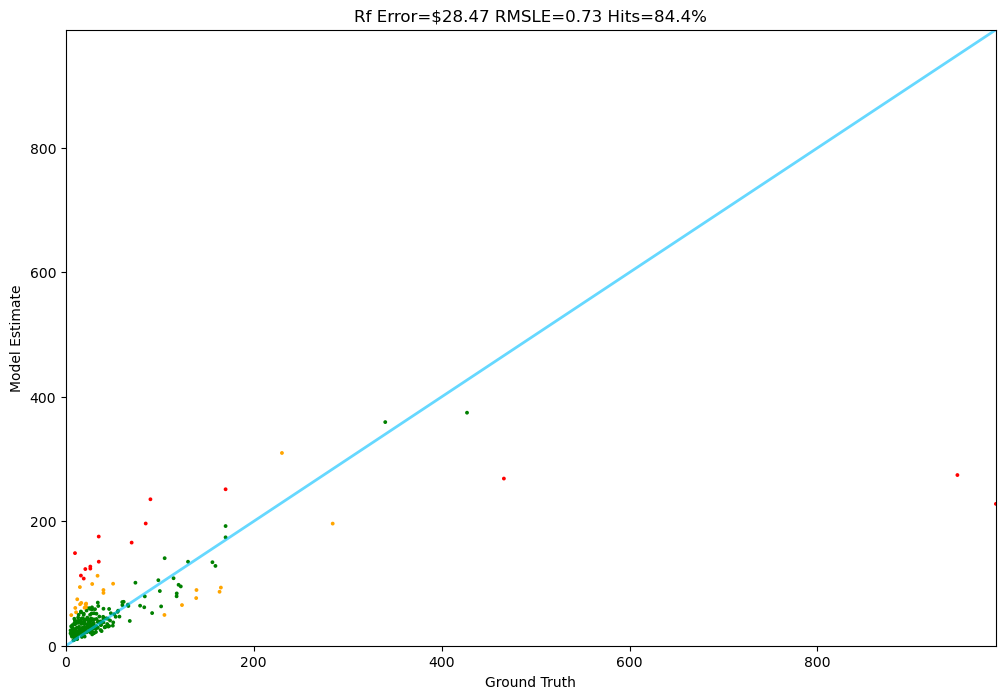

In [25]:
Tester.test(rf, test)

In [26]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"

In [27]:
print(specialist.price(product))
print(frontier.price(product))
print(random_forest.price(product))

189.0


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


99.99
136.04324999999997


In [28]:
specialists = []
frontiers = []
random_forests = []
prices = []
for item in tqdm(test[1000:1250]):
    text = description(item)
    specialists.append(specialist.price(text))
    frontiers.append(frontier.price(text))
    random_forests.append(random_forest.price(text))
    prices.append(item.price)

  0%|                                                                                                                                    | 0/250 [00:00<?, ?it/s]/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
  0%|▍                                                                                                                           | 1/250 [00:02<10:53,  2.63s/it]/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
  1%|▉                                                                                                                           | 2/250 [00:06<13:52,  3.36s/it]/opt/conda/envs

In [29]:
mins = [min(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]
maxes = [max(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier': frontiers,
    'RandomForest': random_forests,
    'Min': mins,
    'Max': maxes,
})

# Convert y to a Series
y = pd.Series(prices)

In [30]:
# Train a Linear Regression
np.random.seed(42)

lr = LinearRegression()
lr.fit(X, y)

feature_columns = X.columns.tolist()

for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

Specialist: 0.95
Frontier: 0.09
RandomForest: 0.19
Min: 0.25
Max: -0.31
Intercept=-5.53


In [31]:
joblib.dump(lr, 'ensemble_model.pkl')

['ensemble_model.pkl']

In [32]:
from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

In [33]:
ensemble.price(product)

/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


175.43064464420357

In [34]:
def ensemble_pricer(item):
    return max(0,ensemble.price(description(item)))

/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


1: Guess: $62.35 Truth: $65.99 Error: $3.64 SLE: 0.00 Item: Setpower Insulated Protective Cover for ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


2: Guess: $0.00 Truth: $9.68 Error: $9.68 SLE: 5.61 Item: TUAIC Refrigerator Door Light Switch 2 F...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


3: Guess: $172.20 Truth: $155.98 Error: $16.22 SLE: 0.01 Item: Kegco Secondary Regulator, 3 Product, Ch...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


4: Guess: $0.00 Truth: $5.59 Error: $5.59 SLE: 3.56 Item: MHY62044106 Refrigerator Door Spring 2Pc...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


5: Guess: $120.13 Truth: $98.40 Error: $21.73 SLE: 0.04 Item: Ice-O-Matic 9131111-01 Float Valve


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


6: Guess: $36.14 Truth: $54.99 Error: $18.85 SLE: 0.17 Item: Wireless Temperature & Humidity Bluetoot...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


7: Guess: $0.00 Truth: $5.71 Error: $5.71 SLE: 3.62 Item: 3Inch Thermometer Hygrometer for Indoor ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


8: Guess: $11.14 Truth: $9.53 Error: $1.61 SLE: 0.02 Item: GE WH1X2754 GE Timer Knob Assembly,white


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


9: Guess: $13.95 Truth: $11.24 Error: $2.71 SLE: 0.04 Item: newlifeapp 33001003 Dryer Lint Screen Fi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


10: Guess: $13.86 Truth: $12.88 Error: $0.98 SLE: 0.00 Item: Away NV350 NV351 NV352 NV355 NV356 NV357...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


11: Guess: $167.60 Truth: $99.99 Error: $67.61 SLE: 0.26 Item: IM116000 Refrigerator Ice Maker Genuine ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


12: Guess: $16.09 Truth: $16.99 Error: $0.90 SLE: 0.00 Item: 2 PACKS DLSC002 Water Filter Compatible ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


13: Guess: $11.33 Truth: $12.74 Error: $1.41 SLE: 0.01 Item: STANCO METAL PROD 410-8 8"Elec NonstickS...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


14: Guess: $1.29 Truth: $10.95 Error: $9.66 SLE: 2.73 Item: GE WB32X10012 6-Inch Drip Pan


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


15: Guess: $55.07 Truth: $66.50 Error: $11.43 SLE: 0.03 Item: Edgewater Parts WH23X10016 Drain Pump Co...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


16: Guess: $1.94 Truth: $11.99 Error: $10.05 SLE: 2.21 Item: Elyum Size 04 Cone Coffee Filters, Natur...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


17: Guess: $48.04 Truth: $49.95 Error: $1.91 SLE: 0.00 Item: Everydrop by Whirlpool Ice and Water Ref...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


18: Guess: $52.31 Truth: $26.92 Error: $25.39 SLE: 0.42 Item: Beverage Air 703-587C Door Gasket


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


19: Guess: $129.56 Truth: $89.98 Error: $39.58 SLE: 0.13 Item: Frigidaire EFIC123-SS Counter Top Maker,...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


20: Guess: $72.31 Truth: $25.99 Error: $46.32 SLE: 1.00 Item: Supplying Demand 316203200 316199900 Ele...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


21: Guess: $2.23 Truth: $17.99 Error: $15.76 SLE: 3.13 Item: 2-Pack 37001142 Dryer Lint Filter Replac...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


22: Guess: $21.03 Truth: $6.99 Error: $14.04 SLE: 1.03 Item: Qlear-CLWT Premium Replacement Coffee Ma...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


23: Guess: $0.00 Truth: $39.99 Error: $39.99 SLE: 13.79 Item: HUBBELL HBL5666CA AC Plug NEMA 6-15 Male...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


24: Guess: $21.38 Truth: $13.99 Error: $7.39 SLE: 0.16 Item: Refrigerator Egg Holder With Lid - Super...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


25: Guess: $433.43 Truth: $339.95 Error: $93.48 SLE: 0.06 Item: ZLINE 20.5" Ducted Wall Mount Range Hood...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


26: Guess: $49.52 Truth: $67.99 Error: $18.47 SLE: 0.10 Item: Supplying Demand W10919003 W10775446 Top...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


27: Guess: $97.31 Truth: $139.00 Error: $41.69 SLE: 0.12 Item: Compatible Ice Maker for Whirlpool GZ25F...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


28: Guess: $13.07 Truth: $8.97 Error: $4.10 SLE: 0.12 Item: Blutoget 6" Louvered Vent Cover for Exte...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


29: Guess: $21.17 Truth: $39.65 Error: $18.48 SLE: 0.37 Item: Edgewater Parts WR60X23584, AP5955766, P...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


30: Guess: $320.08 Truth: $229.98 Error: $90.10 SLE: 0.11 Item: Winflo 30 In. Convertible Stainless Stee...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


31: Guess: $22.29 Truth: $25.80 Error: $3.51 SLE: 0.02 Item: 383EER3001G 4901ER2003A 383EER3001J 383E...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


32: Guess: $0.39 Truth: $11.99 Error: $11.60 SLE: 4.99 Item: 2 PACK AF Compatible Replacement For Sam...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


33: Guess: $6.60 Truth: $9.99 Error: $3.39 SLE: 0.14 Item: Poweka Refillable Coffee Capsules Pods R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


34: Guess: $22.33 Truth: $21.99 Error: $0.34 SLE: 0.00 Item: 2-Pack Replacement for Jenn-Air JCD2297K...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


35: Guess: $15.99 Truth: $17.90 Error: $1.91 SLE: 0.01 Item: Supco DE019AC Dryer Heating Element Rest...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


36: Guess: $64.60 Truth: $84.00 Error: $19.40 SLE: 0.07 Item: Frymaster 826-1526 Common Electric Repla...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


37: Guess: $0.00 Truth: $16.24 Error: $16.24 SLE: 8.11 Item: Plumb Craft 7508800N 5-Foot Washing Mach...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


38: Guess: $34.74 Truth: $23.99 Error: $10.75 SLE: 0.13 Item: Overbest DA97-17376B Replacement for Sam...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


39: Guess: $16.48 Truth: $6.99 Error: $9.49 SLE: 0.61 Item: Fill 'n Brew Individual Disposable Coffe...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


40: Guess: $35.42 Truth: $24.99 Error: $10.43 SLE: 0.11 Item: Maytag UKF7003 EDR7D1 Comparable Refrige...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


41: Guess: $14.24 Truth: $11.61 Error: $2.63 SLE: 0.04 Item: Coffee Filters - Natural Unbleached Brow...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


42: Guess: $804.63 Truth: $949.00 Error: $144.37 SLE: 0.03 Item: EdgeStar 20 Inch Wide 4.3 Cu. Ft. Medica...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


43: Guess: $73.94 Truth: $74.00 Error: $0.06 SLE: 0.00 Item: Bosch 00677095 Door Lower Bin, Clear


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


44: Guess: $66.86 Truth: $22.05 Error: $44.81 SLE: 1.17 Item: Samsung DA34-10120E Switch Door-F


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


45: Guess: $221.51 Truth: $284.00 Error: $62.49 SLE: 0.06 Item: Jenn air JGA8100ADB Stove Cartridge Asse...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


46: Guess: $73.32 Truth: $91.78 Error: $18.46 SLE: 0.05 Item: Whole Parts Burner Grate (Black) Part # ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


47: Guess: $43.43 Truth: $45.20 Error: $1.77 SLE: 0.00 Item: DEFLECTO SK8WF Supurr-Flex(R) 8ft Dryer ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


48: Guess: $19.06 Truth: $8.69 Error: $10.37 SLE: 0.53 Item: Supco RR109 Receptacle Kit


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


49: Guess: $10.77 Truth: $16.18 Error: $5.41 SLE: 0.14 Item: 33001003 Dryer Lint Screen Filter Replac...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


50: Guess: $1.41 Truth: $6.50 Error: $5.09 SLE: 1.29 Item: W10194422 Replacement Light Bulb 40 Watt...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


51: Guess: $13.38 Truth: $32.21 Error: $18.83 SLE: 0.70 Item: ForeverPRO 8532165 Drum Light Lens for W...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


52: Guess: $21.62 Truth: $15.39 Error: $6.23 SLE: 0.10 Item: Highcraft Dishwasher Water Supply Line, ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


53: Guess: $14.43 Truth: $17.99 Error: $3.56 SLE: 0.04 Item: 316048413 and 316048414 Stove Burner Dri...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


54: Guess: $27.42 Truth: $26.99 Error: $0.43 SLE: 0.00 Item: ReplacementBrand 8171413 Comparable Repl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


55: Guess: $2.22 Truth: $11.99 Error: $9.77 SLE: 1.95 Item: 2-Pack 341241 Dryer Drum Belt Replacemen...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


56: Guess: $12.74 Truth: $44.46 Error: $31.72 SLE: 1.43 Item: WP9870163 9870163 Power Nut Kit - Compat...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


57: Guess: $3.90 Truth: $15.99 Error: $12.09 SLE: 1.54 Item: Stovetop Extender SE23WHI Oven Gap Guard...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


58: Guess: $114.44 Truth: $129.99 Error: $15.55 SLE: 0.02 Item: COSVALVE Portable Washing Machine 17lbs ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


59: Guess: $26.90 Truth: $24.99 Error: $1.91 SLE: 0.01 Item: AlaSou Washer Dustproof Cover Front Load...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


60: Guess: $26.52 Truth: $27.38 Error: $0.86 SLE: 0.00 Item: Honeywell HC26E1004/U Pad for He200, He2...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


61: Guess: $16.19 Truth: $16.95 Error: $0.76 SLE: 0.00 Item: HQRP 2-Pack Wick Filter Compatible with ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


62: Guess: $0.00 Truth: $10.82 Error: $10.82 SLE: 6.10 Item: Whirlpool 8537982 Pad Washer


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


63: Guess: $15.10 Truth: $19.00 Error: $3.90 SLE: 0.05 Item: Durable Disposable Electric Burner Bibs-...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


64: Guess: $16.58 Truth: $12.98 Error: $3.60 SLE: 0.05 Item: Anti Vibration Pads for Washing Machine,...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


65: Guess: $14.31 Truth: $16.99 Error: $2.68 SLE: 0.03 Item: Reusable K Cups for Keurig, Reusable Cof...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


66: Guess: $23.08 Truth: $24.97 Error: $1.89 SLE: 0.01 Item: Apace Living Pour Over Coffee Filter - W...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


67: Guess: $5.63 Truth: $10.91 Error: $5.28 SLE: 0.34 Item: Kitchen Basics 101 2 Pack ES18806 Refrig...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


68: Guess: $14.54 Truth: $14.98 Error: $0.44 SLE: 0.00 Item: Mist LT1000P Water Filter Replacement, C...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


69: Guess: $15.79 Truth: $7.90 Error: $7.89 SLE: 0.40 Item: NEW Dryer Drum Felt Replacement for Whir...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


70: Guess: $21.58 Truth: $25.75 Error: $4.17 SLE: 0.03 Item: Cobectal 4581EL2002C Dryer Drum Roller A...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


71: Guess: $23.79 Truth: $41.77 Error: $17.98 SLE: 0.30 Item: WH01X10343 Washer Shock Absorber 4 Pack ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


72: Guess: $8.16 Truth: $20.68 Error: $12.52 SLE: 0.74 Item: Fafeicy WT2000 110-220V Digital Humidity...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


73: Guess: $102.89 Truth: $69.99 Error: $32.90 SLE: 0.15 Item: TJ. Clothes Dryer, 110V 600W Portable Dr...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


74: Guess: $48.94 Truth: $23.99 Error: $24.95 SLE: 0.48 Item: DC97-16350C Suspension Support Rod and A...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


75: Guess: $50.42 Truth: $28.69 Error: $21.73 SLE: 0.30 Item: Supplying Demand WB24X22341 WB24X40331 E...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


76: Guess: $28.61 Truth: $42.00 Error: $13.39 SLE: 0.14 Item: General Electric WB03X24360 Knob Assembl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


77: Guess: $71.21 Truth: $123.57 Error: $52.36 SLE: 0.30 Item: Frigidaire 5304445529 Oven Door Hinge, G...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


78: Guess: $12.45 Truth: $8.99 Error: $3.46 SLE: 0.09 Item: Waytiffer Gas Burner Liners (50 Pack) 8....


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


79: Guess: $48.86 Truth: $36.95 Error: $11.91 SLE: 0.07 Item: USA Made MSWF Compatible by Instapure NS...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


80: Guess: $2.44 Truth: $11.99 Error: $9.55 SLE: 1.76 Item: 2-Pack 341241 Dryer Drum Belt Replacemen...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


81: Guess: $29.11 Truth: $41.30 Error: $12.19 SLE: 0.12 Item: Washing Machine Hoses and Steam Dryer In...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


82: Guess: $24.08 Truth: $35.61 Error: $11.53 SLE: 0.14 Item: Bosch 12004119 Dishwasher Door Spring an...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


83: Guess: $202.53 Truth: $169.99 Error: $32.54 SLE: 0.03 Item: Broan QS336AA QS3 Series Range Hood, 36-...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


84: Guess: $68.21 Truth: $19.91 Error: $48.30 SLE: 1.43 Item: Bosch 00631633 Range Surface Burner Igni...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


85: Guess: $14.47 Truth: $9.57 Error: $4.90 SLE: 0.15 Item: LONYE 9759242 Oven Thermal Fuse Replacem...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


86: Guess: $28.02 Truth: $29.69 Error: $1.67 SLE: 0.00 Item: Upgrade W10594481 Stainless Steel Cooker...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


87: Guess: $70.06 Truth: $21.93 Error: $48.13 SLE: 1.28 Item: Supco IMM8366 Icemaker Control Module, R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


88: Guess: $21.97 Truth: $32.56 Error: $10.59 SLE: 0.14 Item: DA31-00334C (AP6803162) Evaporator Fan M...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


89: Guess: $26.99 Truth: $22.78 Error: $4.21 SLE: 0.03 Item: UPGRADE 240363702 Refrigerator Door Bin ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


90: Guess: $22.08 Truth: $24.79 Error: $2.71 SLE: 0.01 Item: Supreme Covers Portable Washing Machine ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


91: Guess: $70.23 Truth: $33.69 Error: $36.54 SLE: 0.52 Item: Frigidaire 316206401 Surface Burner Base...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


92: Guess: $15.89 Truth: $12.99 Error: $2.90 SLE: 0.04 Item: TooCust Milk Frothing Pitcher 20 OZ/600M...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


93: Guess: $41.14 Truth: $12.99 Error: $28.15 SLE: 1.22 Item: Premium Vials 38-28SWB-ZT 38 x 28 mm Cle...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


94: Guess: $5.90 Truth: $10.98 Error: $5.08 SLE: 0.30 Item: 8318084 AP3180933 PS886960 Washer Door L...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


95: Guess: $44.46 Truth: $26.44 Error: $18.02 SLE: 0.25 Item: Aqua Fresh 4396508 Replacement Water Fil...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


96: Guess: $15.24 Truth: $16.99 Error: $1.75 SLE: 0.01 Item: InterDesign Covered Egg Holder - Refrige...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


97: Guess: $21.63 Truth: $25.25 Error: $3.62 SLE: 0.02 Item: Upgrade DG94-00520A Gas Range Oven Flat ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


98: Guess: $13.09 Truth: $11.88 Error: $1.21 SLE: 0.01 Item: 383EER4001A Washing Machine Inner/Outer ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


99: Guess: $26.37 Truth: $28.99 Error: $2.62 SLE: 0.01 Item: Maxmartt 100mm Vent Cover Stainless Stee...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


100: Guess: $19.62 Truth: $23.12 Error: $3.50 SLE: 0.02 Item: Upgraded Lifetime Appliance WR72X239 Cri...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


101: Guess: $71.58 Truth: $52.97 Error: $18.61 SLE: 0.09 Item: Whirlpool W10181986 Sensor for Range, Si...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


102: Guess: $27.73 Truth: $25.99 Error: $1.74 SLE: 0.00 Item: Wintact Digital Temperature and Humidity...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


103: Guess: $14.98 Truth: $17.99 Error: $3.01 SLE: 0.03 Item: BOTNA 97006931 Range Hood Grease Filter ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


104: Guess: $9.31 Truth: $7.99 Error: $1.32 SLE: 0.02 Item: Milk Frothing Pitcher 12oz, Espresso Cap...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


105: Guess: $27.15 Truth: $28.99 Error: $1.84 SLE: 0.00 Item: 1040 Replacement Wick for AIRCARE, Essic...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


106: Guess: $17.44 Truth: $12.07 Error: $5.37 SLE: 0.12 Item: Stanco Gas Range Drip Pan For Gas Ranges...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


107: Guess: $27.89 Truth: $18.99 Error: $8.90 SLE: 0.14 Item: Dampp Chaser Piano Humidifier Pad Treatm...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


108: Guess: $0.00 Truth: $9.99 Error: $9.99 SLE: 5.75 Item: Gardens 216822900 Light Switch Fits Frig...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


109: Guess: $47.30 Truth: $29.99 Error: $17.31 SLE: 0.20 Item: Waterspecialist DA97-17376B Replacement ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


110: Guess: $14.77 Truth: $9.99 Error: $4.78 SLE: 0.13 Item: Upgraded WB03X24818 Stove Knob, Stainles...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


111: Guess: $43.03 Truth: $31.69 Error: $11.34 SLE: 0.09 Item: 5-PACK Top Burner Control Dial Knob Rang...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


112: Guess: $22.71 Truth: $24.99 Error: $2.28 SLE: 0.01 Item: Large Capacity Egg Holder for Refrigerat...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


113: Guess: $23.58 Truth: $25.99 Error: $2.41 SLE: 0.01 Item: FireFly Home Stove Top Protector for LG ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


114: Guess: $6.03 Truth: $18.99 Error: $12.96 SLE: 1.09 Item: Annbully Cartoon USB Mini Mushroom Light...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


115: Guess: $2.05 Truth: $9.99 Error: $7.94 SLE: 1.64 Item: Goldenvalueable 6 x Single Coffee Pod Fi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


116: Guess: $30.01 Truth: $22.99 Error: $7.02 SLE: 0.07 Item: Blueangle Pink Hibiscus Dishwasher Magne...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


117: Guess: $237.83 Truth: $169.99 Error: $67.84 SLE: 0.11 Item: ROVSUN 13LBS Portable Washing Machine, 1...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


118: Guess: $46.96 Truth: $36.99 Error: $9.97 SLE: 0.05 Item: 1-Year Warranty 137114000 Dryer Heating ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


119: Guess: $25.15 Truth: $33.99 Error: $8.84 SLE: 0.08 Item: ICEPURE 46-9690 ADQ36006101 Replacement ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


120: Guess: $72.08 Truth: $104.89 Error: $32.81 SLE: 0.14 Item: Whirlpool W10833899 Water Inlet Valve, W...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


121: Guess: $29.59 Truth: $19.98 Error: $9.61 SLE: 0.14 Item: W11036930 Washing Machine Water Valve FO...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


122: Guess: $0.98 Truth: $9.99 Error: $9.01 SLE: 2.94 Item: Sunflowers Refrigerator Door Handle Cove...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


123: Guess: $13.09 Truth: $28.10 Error: $15.01 SLE: 0.53 Item: General Electric WR17X3880 Front Shelf R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


124: Guess: $44.36 Truth: $27.50 Error: $16.86 SLE: 0.22 Item: Supco Refrigerator Water Valve for Whirl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


125: Guess: $34.30 Truth: $36.99 Error: $2.69 SLE: 0.01 Item: HASMX 6-918873 Dishwasher Cutlery Silver...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


126: Guess: $24.97 Truth: $19.84 Error: $5.13 SLE: 0.05 Item: Whirlpool W10437088 Range Surface Burner...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


127: Guess: $23.46 Truth: $24.99 Error: $1.53 SLE: 0.00 Item: 950S - Compatible with GE Square Gas Ran...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


128: Guess: $145.56 Truth: $169.99 Error: $24.43 SLE: 0.02 Item: WAFIET 12 Inch Gas Cooktop with 2 Italy ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


129: Guess: $14.26 Truth: $19.99 Error: $5.73 SLE: 0.10 Item: Reusable Vertuo Capsule Cap + Coffee Pod...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


130: Guess: $16.22 Truth: $25.95 Error: $9.73 SLE: 0.20 Item: Coffee Filter Holder - Coffee Filter Sto...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


131: Guess: $183.72 Truth: $39.96 Error: $143.76 SLE: 2.27 Item: Star 2F-Z3036 Deflector-Burner Cast


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


132: Guess: $11.30 Truth: $15.99 Error: $4.69 SLE: 0.10 Item: General Electric WB17T10006 Range Surfac...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


133: Guess: $21.89 Truth: $39.99 Error: $18.10 SLE: 0.34 Item: WiFi Temperature Sensor with Waterproof ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


134: Guess: $18.63 Truth: $21.53 Error: $2.90 SLE: 0.02 Item: KITCHEN BASICS 101: 1 Piece 5304439835 F...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


135: Guess: $29.91 Truth: $26.99 Error: $2.92 SLE: 0.01 Item: Dryer Heating Element for Samsung，DC47-0...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


136: Guess: $45.21 Truth: $43.99 Error: $1.22 SLE: 0.00 Item: Samsung DA29-00020B, DA29-00020A, HAF-CI...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


137: Guess: $12.67 Truth: $9.41 Error: $3.26 SLE: 0.07 Item: HQRP 3-Pack Wick Filter Compatible with ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


138: Guess: $5.25 Truth: $8.99 Error: $3.74 SLE: 0.22 Item: Reusable K Cups For Keurig K-Latte 1.0 C...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


139: Guess: $88.64 Truth: $61.51 Error: $27.13 SLE: 0.13 Item: IM10093 for WR30X10093 GE Icemaker Refri...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


140: Guess: $82.67 Truth: $122.30 Error: $39.63 SLE: 0.15 Item: Whirlpool W10159839 Inlet Valve


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


141: Guess: $6.25 Truth: $14.89 Error: $8.64 SLE: 0.62 Item: 100 UNIVERSAL Round Aluminum Foil Gas Bu...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


142: Guess: $71.79 Truth: $39.99 Error: $31.80 SLE: 0.33 Item: TRUE 811502 Nozzle and Screw Set


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


143: Guess: $6.45 Truth: $17.90 Error: $11.45 SLE: 0.87 Item: Dianoo Espresso Steaming Pitcher, Espres...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


144: Guess: $43.12 Truth: $16.77 Error: $26.35 SLE: 0.83 Item: Air Filter Factory Replacement For Lenno...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


145: Guess: $75.39 Truth: $23.99 Error: $51.40 SLE: 1.25 Item: EvertechPRO Washer Drain Pump Assembly R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


146: Guess: $72.22 Truth: $35.00 Error: $37.22 SLE: 0.50 Item: Cheftek CT1010 Portable 2 Burner Electri...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


147: Guess: $5.58 Truth: $4.95 Error: $0.63 SLE: 0.01 Item: HQRP 4 Pin Universal Refrigerator Freeze...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


148: Guess: $13.07 Truth: $18.89 Error: $5.82 SLE: 0.12 Item: 2-Pack W10189190 TSD2 Start Device & W10...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


149: Guess: $13.91 Truth: $8.77 Error: $5.14 SLE: 0.18 Item: Air Filter Factory Replacement For Whirl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


150: Guess: $39.45 Truth: $17.22 Error: $22.23 SLE: 0.64 Item: Plumb Pak Braided Washing Machine Hose, ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


151: Guess: $65.87 Truth: $20.98 Error: $44.89 SLE: 1.24 Item: Bosch 00424673 Button, Silver


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


152: Guess: $29.41 Truth: $37.37 Error: $7.96 SLE: 0.05 Item: Siwdoy 4391960 279816 3392519 Dryer Heat...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


153: Guess: $14.26 Truth: $11.99 Error: $2.27 SLE: 0.03 Item: OUGAR8 Refrigerator Door Handle Covers H...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


154: Guess: $99.86 Truth: $119.95 Error: $20.09 SLE: 0.03 Item: Bosch 00414750 Range Hood Fan Switch Gen...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


155: Guess: $71.33 Truth: $31.00 Error: $40.33 SLE: 0.67 Item: Replacement Filter Compatible with HG Ty...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


156: Guess: $52.15 Truth: $31.00 Error: $21.15 SLE: 0.26 Item: Aprilaire Humidifier Part # 10 for Model...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


157: Guess: $16.47 Truth: $7.97 Error: $8.50 SLE: 0.44 Item: Technivorm Moccamaster 85090 Cup-One Pap...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


158: Guess: $67.59 Truth: $51.50 Error: $16.09 SLE: 0.07 Item: LG Electronics 4681EA1007D 4681EA2001T W...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


159: Guess: $27.86 Truth: $27.99 Error: $0.13 SLE: 0.00 Item: ALAZA Flower on Marble Art Large Dishwas...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


160: Guess: $474.39 Truth: $466.24 Error: $8.15 SLE: 0.00 Item: Frigidaire FFEC3025UB 30 Inch Electric S...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


161: Guess: $61.60 Truth: $50.36 Error: $11.24 SLE: 0.04 Item: General Electric WR8X122 Refrigerator Ov...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


162: Guess: $13.17 Truth: $19.97 Error: $6.80 SLE: 0.15 Item: Small Size Pour Over Coffee filter Paper...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


163: Guess: $25.84 Truth: $29.95 Error: $4.11 SLE: 0.02 Item: Sealegend 6-Pieces Dryer Vent Cleaner Ki...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


164: Guess: $43.60 Truth: $23.99 Error: $19.61 SLE: 0.34 Item: Waterspecialist XWF NSF Certified Refrig...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


165: Guess: $6.33 Truth: $12.74 Error: $6.41 SLE: 0.39 Item: GARP 279816 Compatible Replacement for D...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


166: Guess: $1.02 Truth: $8.99 Error: $7.97 SLE: 2.56 Item: Premium W10258275 Dishwasher Bimetal The...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


167: Guess: $22.33 Truth: $24.99 Error: $2.66 SLE: 0.01 Item: UpStart Components Replacement for Gener...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


168: Guess: $19.72 Truth: $17.99 Error: $1.73 SLE: 0.01 Item: Chef's Star Stainless Steel Milk Frothin...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


169: Guess: $16.34 Truth: $19.99 Error: $3.65 SLE: 0.04 Item: Egg Container for Refrigerator 2 Layer E...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


170: Guess: $25.08 Truth: $18.77 Error: $6.31 SLE: 0.08 Item: AMI PARTS DC97-16742A Dryer Lint Filter ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


171: Guess: $55.49 Truth: $47.86 Error: $7.63 SLE: 0.02 Item: GE WB2X9154 Igniter for Gas Broiler or O...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


172: Guess: $68.74 Truth: $34.45 Error: $34.29 SLE: 0.46 Item: General Electric WE25X218 Dryer Conversi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


173: Guess: $2.53 Truth: $7.99 Error: $5.46 SLE: 0.88 Item: 312959 Dryer Belt Replacement for Maytag...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


174: Guess: $37.80 Truth: $27.99 Error: $9.81 SLE: 0.08 Item: 5-Pack Replacement EF-1 Filter for Kenmo...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


175: Guess: $107.55 Truth: $117.99 Error: $10.44 SLE: 0.01 Item: OEM Samsung Refrigerator Door Bin Basket...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


176: Guess: $575.08 Truth: $989.99 Error: $414.91 SLE: 0.29 Item: vevor 24" Undercounter Built-in Refriger...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


177: Guess: $15.19 Truth: $18.99 Error: $3.80 SLE: 0.04 Item: Reusable Vertuo Capsule Kit for Nespress...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


178: Guess: $189.96 Truth: $164.98 Error: $24.98 SLE: 0.02 Item: 32" x 30" 2.5" Heavy Duty Washer Machine...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


179: Guess: $40.77 Truth: $19.36 Error: $21.41 SLE: 0.52 Item: Fluidmaster 9WM60 "No Burst" Washing Mac...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


180: Guess: $12.41 Truth: $16.00 Error: $3.59 SLE: 0.06 Item: AYZE 5300622034 AP2135128 Electric Restr...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


181: Guess: $41.53 Truth: $21.40 Error: $20.13 SLE: 0.41 Item: Whirlpool 8559751 Door Handle, Black


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


182: Guess: $23.13 Truth: $46.99 Error: $23.86 SLE: 0.47 Item: Upgraded Dryer Repair Kit Compatible wit...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


183: Guess: $17.19 Truth: $13.69 Error: $3.50 SLE: 0.05 Item: Camco 00553 8" GE/Hotpoint Hinge Reflect...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


184: Guess: $28.49 Truth: $22.72 Error: $5.77 SLE: 0.05 Item: GE Part Number WB03T10272 KNOB SELECTOR ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


185: Guess: $86.85 Truth: $105.13 Error: $18.28 SLE: 0.04 Item: Manitowoc Ice 4304643 Curtain, Water


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


186: Guess: $46.69 Truth: $32.50 Error: $14.19 SLE: 0.12 Item: EXP279838 Heating Element ( Replaces 279...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


187: Guess: $75.48 Truth: $114.60 Error: $39.12 SLE: 0.17 Item: Vulcan Hart 346357-1 Thermo


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


188: Guess: $64.80 Truth: $84.96 Error: $20.16 SLE: 0.07 Item: Turbo Air 30283N0100 Thermostat


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


189: Guess: $75.87 Truth: $83.40 Error: $7.53 SLE: 0.01 Item: Frigidaire 241679003 Dispenser Trim Refr...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


190: Guess: $17.40 Truth: $9.99 Error: $7.41 SLE: 0.27 Item: W10721967 Splutch Cam Kit Replacement fo...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


191: Guess: $0.92 Truth: $9.49 Error: $8.57 SLE: 2.89 Item: newlifeapp 40113801 Dryer Thermal Cut of...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


192: Guess: $14.68 Truth: $29.99 Error: $15.31 SLE: 0.46 Item: Upgraded W10612022 Dryer Rear Drum Felt ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


193: Guess: $24.75 Truth: $13.57 Error: $11.18 SLE: 0.32 Item: 2 Pack Top Burner Spark Igniter Range Re...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


194: Guess: $21.50 Truth: $19.96 Error: $1.54 SLE: 0.01 Item: 8540024 Washer Drain Pump Motor by Seent...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


195: Guess: $49.05 Truth: $56.99 Error: $7.94 SLE: 0.02 Item: New-Refrigerator Icemaker Module Compati...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


196: Guess: $10.02 Truth: $16.37 Error: $6.35 SLE: 0.21 Item: Whirlpool W10195839 Adjuster


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


197: Guess: $22.79 Truth: $19.99 Error: $2.80 SLE: 0.02 Item: Nispira Replacement Range Hood Grease Fi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


198: Guess: $27.33 Truth: $37.98 Error: $10.65 SLE: 0.10 Item: Mist Water Filter Replacement, Compatibl...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


199: Guess: $48.38 Truth: $34.79 Error: $13.59 SLE: 0.10 Item: (2-Pack) UPGRADE 240356402 Refrigerator ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


200: Guess: $0.96 Truth: $8.39 Error: $7.43 SLE: 2.45 Item: DPD 3949238 Washer Lid Switch Assembly R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


201: Guess: $123.11 Truth: $117.86 Error: $5.25 SLE: 0.00 Item: GENUINE Frigidaire 318050800 Bake Elemen...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


202: Guess: $12.68 Truth: $15.99 Error: $3.31 SLE: 0.05 Item: Anti Vibration Pads for Washing Machine,...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


203: Guess: $14.17 Truth: $10.99 Error: $3.18 SLE: 0.06 Item: 8536974 Dryer Drum Support Roller Kit, R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


204: Guess: $30.09 Truth: $24.43 Error: $5.66 SLE: 0.04 Item: Whirlpool 279816 Dryer Thermal Fuse Kit


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


205: Guess: $435.07 Truth: $426.98 Error: $8.09 SLE: 0.00 Item: Empava 36 500 CFM Island Range Hood Duct...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


206: Guess: $49.18 Truth: $39.99 Error: $9.19 SLE: 0.04 Item: SpiroPure SP-LE700 NSF Certified Refrige...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


207: Guess: $45.94 Truth: $26.99 Error: $18.95 SLE: 0.27 Item: Replacement for Jenn-Air A100W 8 inch 5 ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


208: Guess: $110.98 Truth: $138.69 Error: $27.71 SLE: 0.05 Item: GE WR49X10091 Genuine OEM Damper Control...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


209: Guess: $1.81 Truth: $13.97 Error: $12.16 SLE: 2.80 Item: DC47-00016A Dryer Thermal Fuse Thermosta...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


210: Guess: $16.51 Truth: $21.99 Error: $5.48 SLE: 0.07 Item: 2-Pack Replacement for JFD2589KEP Refrig...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


211: Guess: $7.07 Truth: $18.88 Error: $11.81 SLE: 0.81 Item: WP33001244 33001244 Terminal Block Assem...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


212: Guess: $64.11 Truth: $18.41 Error: $45.70 SLE: 1.46 Item: Whirlpool 308180 Bake, Black


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


213: Guess: $22.02 Truth: $9.95 Error: $12.07 SLE: 0.55 Item: LG 6501KW2001B 6501KW2001A Sensor Kenmor...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


214: Guess: $12.91 Truth: $18.00 Error: $5.09 SLE: 0.10 Item: Compatible Drum Belt for Maytag MDE2500A...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


215: Guess: $23.06 Truth: $33.95 Error: $10.89 SLE: 0.14 Item: Whirlpool MAL9000AXX Dryer Liquid Propan...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


216: Guess: $41.01 Truth: $42.95 Error: $1.94 SLE: 0.00 Item: MCGILL Replacement Black Fan Rocker Swit...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


217: Guess: $53.75 Truth: $59.99 Error: $6.24 SLE: 0.01 Item: New Upgraded 5304507199 Refrigerator Doo...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


218: Guess: $76.88 Truth: $55.58 Error: $21.30 SLE: 0.10 Item: TRUE 810719 Black Gasket For Gdm-19/23/4...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


219: Guess: $69.27 Truth: $15.10 Error: $54.17 SLE: 2.17 Item: LG 5215EA3003A Genuine OEM Drain Hose As...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


220: Guess: $39.51 Truth: $45.99 Error: $6.48 SLE: 0.02 Item: Waterspecialist DA29-00020B Refrigerator...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


221: Guess: $77.23 Truth: $60.14 Error: $17.09 SLE: 0.06 Item: GlobPro W10321032 1876931 Washer Water D...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


222: Guess: $32.04 Truth: $45.99 Error: $13.95 SLE: 0.12 Item: AQUA CREST 847200 Refrigerator Water Fil...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


223: Guess: $14.40 Truth: $16.24 Error: $1.84 SLE: 0.01 Item: Frigidaire 297216600 Frigidare Thermosta...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


224: Guess: $15.92 Truth: $31.99 Error: $16.07 SLE: 0.45 Item: Supplying Demand 8557884 W10874409 Cloth...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


225: Guess: $21.13 Truth: $34.00 Error: $12.87 SLE: 0.21 Item: Whole Parts 3398095 Dryer Push To Start ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


226: Guess: $16.42 Truth: $26.99 Error: $10.57 SLE: 0.22 Item: i Cafillas Refillable Stainless Steel Co...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


227: Guess: $24.93 Truth: $15.39 Error: $9.54 SLE: 0.21 Item: er2198202 Thermostat


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


228: Guess: $52.02 Truth: $27.77 Error: $24.25 SLE: 0.37 Item: Beaquicy WB44X5082 Oven Bake Element - R...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


229: Guess: $16.32 Truth: $26.08 Error: $9.76 SLE: 0.20 Item: Whirlpool 661570 Belt


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


230: Guess: $45.57 Truth: $18.99 Error: $26.58 SLE: 0.72 Item: iFillMug 33 Pack for K Cup and Keurig Br...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


231: Guess: $143.06 Truth: $159.18 Error: $16.12 SLE: 0.01 Item: Frigidaire 5304506131 Freezer Door Gaske...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


232: Guess: $12.93 Truth: $34.95 Error: $22.02 SLE: 0.90 Item: New York Air 737-300 Airplane Miniature ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


233: Guess: $27.90 Truth: $25.19 Error: $2.71 SLE: 0.01 Item: Amazon Basics Replacement GE XWF Refrige...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


234: Guess: $1.13 Truth: $19.51 Error: $18.38 SLE: 5.13 Item: Upgraded 5304506510 Dishrack Stop Clip -...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


235: Guess: $35.93 Truth: $37.45 Error: $1.52 SLE: 0.00 Item: Sportman Pastoral Style Vase Flower Kitc...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


236: Guess: $66.52 Truth: $29.99 Error: $36.53 SLE: 0.61 Item: [4680JB1026H Motor OEM Mania] 4680JB1026...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


237: Guess: $121.29 Truth: $163.56 Error: $42.27 SLE: 0.09 Item: 5304458371 Refrigerator Ice Maker Assemb...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


238: Guess: $13.80 Truth: $27.00 Error: $13.20 SLE: 0.41 Item: WE01X25915 Appliance Slide for General E...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


239: Guess: $1.74 Truth: $5.99 Error: $4.25 SLE: 0.87 Item: W10195416 Lower Dishwasher Wheel Replace...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


240: Guess: $0.63 Truth: $6.64 Error: $6.01 SLE: 2.39 Item: Gas Female Cap ORIFICE 1/8" NPT # .75 (....


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


241: Guess: $15.54 Truth: $26.04 Error: $10.50 SLE: 0.24 Item: 9pcs Silicon Rubber Pad for Bottle Cappi...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


242: Guess: $19.24 Truth: $13.79 Error: $5.45 SLE: 0.10 Item: Supplying Demand 6601EL3001A EBF61496101...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


243: Guess: $124.53 Truth: $78.98 Error: $45.55 SLE: 0.20 Item: General Electric WR24X10184 Refrigerator...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


244: Guess: $0.00 Truth: $27.99 Error: $27.99 SLE: 11.34 Item: i Cafilas New Lid Stainless Steel Refill...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


245: Guess: $16.13 Truth: $14.99 Error: $1.14 SLE: 0.00 Item: GHM Humidifier Replacement Filter E HC14...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


246: Guess: $78.28 Truth: $50.25 Error: $28.03 SLE: 0.19 Item: Manitowoc Ice 000009123 Water Inlet Valv...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


247: Guess: $68.60 Truth: $101.36 Error: $32.76 SLE: 0.15 Item: General Electric WH08X10049 Door Boot Se...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


248: Guess: $12.30 Truth: $4.98 Error: $7.32 SLE: 0.64 Item: Kitchen Stove Gap Cover Stove Count Gap ...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


249: Guess: $1.84 Truth: $9.89 Error: $8.05 SLE: 1.81 Item: W11457841 Washer & Dryer Lid Strike - fo...


/opt/conda/envs/llms/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


250: Guess: $28.35 Truth: $27.99 Error: $0.36 SLE: 0.00 Item: Nispira Humidifier Wick Filter Replaceme...


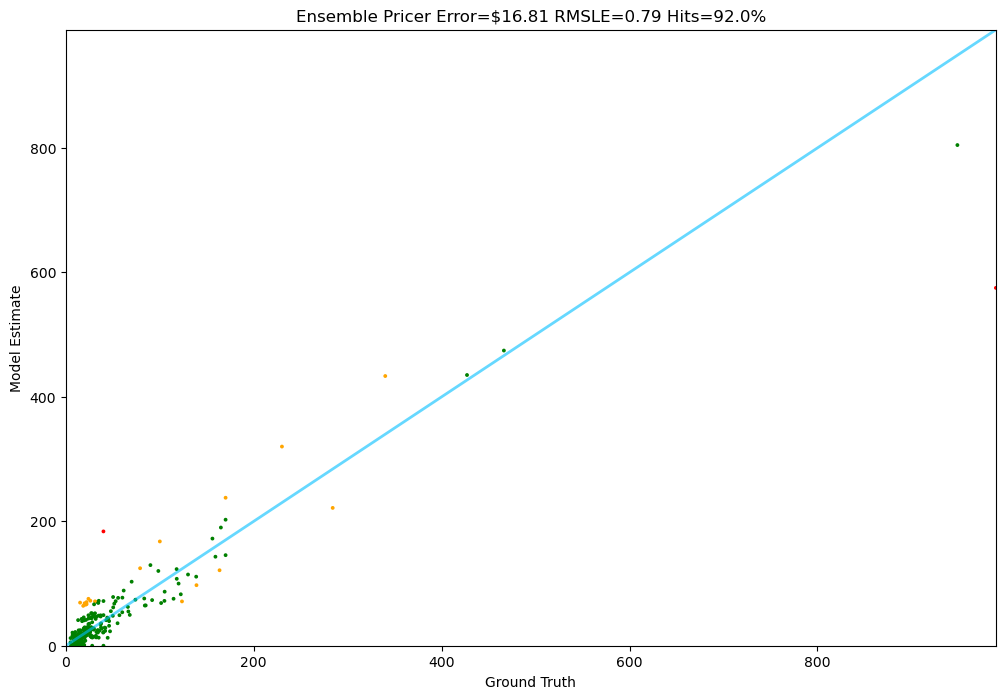

In [35]:
Tester.test(ensemble_pricer, test)

# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.